# 📉 Churn Predictor

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/analytics-accelerator/churn-predictor/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=analytics-accelerator/churn-predictor/demo.ipynb)

> **Pain point:** *We find out customers left after they're gone.*

Churn is cheapest to fix *before* it happens. This trains a gradient-boosted classifier on your history and turns it into three things a retention team can use today: a **risk score** per customer, the **drivers** behind churn, and an honest **held-out evaluation** so you know whether to trust the scores.

**What this notebook covers**
1. The core logic — train, evaluate, score
2. A sample customer base (800 customers, real churn drivers)
3. Held-out model quality (AUC, precision, recall)
4. What actually drives churn
5. The ranked at-risk list


## Step 1 — The core logic

The pipeline: split into train/test, **standardize** features, fit a `GradientBoostingClassifier`, then evaluate on the held-out set so the metrics reflect new customers — not ones the model already saw. It also auto-detects the churn label and drops ID-like columns. Pure scikit-learn, no API keys.

In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from churn import (
    find_label_column,
    sample_customers,
    score_customers,
    select_features,
    train_churn_model,
)

sns.set_theme(style='whitegrid')
print('Core logic loaded.')

Core logic loaded.


## Step 2 — A sample customer base

`sample_customers()` builds a deterministic 800-row base (seed=42) where churn is driven by real signals — short tenure, high charges, lots of support tickets, few logins, and month-to-month contracts — plus noise, so the model has a genuine pattern to learn.

In [2]:
df = sample_customers()
print(f'{len(df)} customers · churn rate {df.churned.mean():.1%}')
print('Label column detected:', find_label_column(df))
print('Features:', select_features(df, 'churned'))
df.head()

800 customers · churn rate 21.0%
Label column detected: churned
Features: ['tenure_months', 'monthly_charges', 'support_tickets', 'logins_last_month', 'is_month_to_month']


,customer_id,tenure_months,monthly_charges,support_tickets,logins_last_month,is_month_to_month,churned
0,1000,7,80.99,2,16,1,0
1,1001,55,83.10,4,10,1,0
2,1002,47,76.91,1,10,1,0
3,1003,32,34.68,1,10,0,0
4,1004,31,15.00,1,10,1,0


## Step 3 — Train and evaluate

One call trains the model and scores it on the held-out 25%. AUC is the headline: 0.5 is a coin flip, 1.0 is perfect.

In [3]:
cm = train_churn_model(df)
for k, v in cm.metrics.items():
    print(f'  {k:14} {v}')

  auc            0.739
  avg_precision  0.428
  precision      0.545
  recall         0.286
  churn_rate     0.21
  n_train        600
  n_test         200


## Step 4 — What drives churn

Feature importances tell the retention team *where to intervene* — not just who's at risk, but why.

In [4]:
imp = pd.DataFrame(cm.importances, columns=['feature', 'importance'])
imp

,feature,importance
0,monthly_charges,0.417
1,tenure_months,0.311
2,logins_last_month,0.145
3,support_tickets,0.086
4,is_month_to_month,0.041


## Step 5 — The ranked at-risk list + drivers chart

`score_customers` returns every customer with a churn probability and a risk band. Sort high-to-low and you have today's outreach list.

In [5]:
scored = score_customers(cm, df)
print('Risk bands:', scored['risk_band'].value_counts().to_dict())
scored[['customer_id', 'churn_risk', 'risk_band',
        'tenure_months', 'monthly_charges', 'support_tickets']].head(10)

Risk bands: {'Low': 629, 'Medium': 122, 'High': 49}


,customer_id,churn_risk,risk_band,tenure_months,monthly_charges,support_tickets
205,1205,0.888,High,19,76.23,7
384,1384,0.850,High,3,113.22,0
459,1459,0.846,High,8,79.14,4
539,1539,0.834,High,2,117.05,1
352,1352,0.828,High,22,29.50,0
417,1417,0.820,High,9,79.48,2
216,1216,0.818,High,6,101.86,2
515,1515,0.817,High,8,72.56,5
411,1411,0.816,High,17,96.48,4
197,1197,0.815,High,9,43.20,0


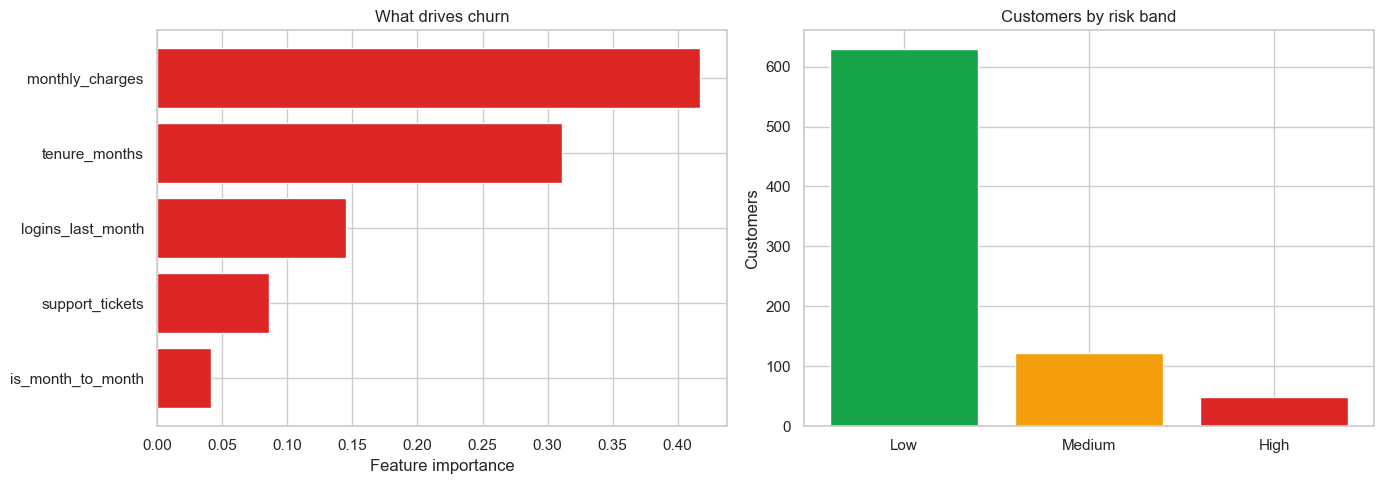

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Drivers
axes[0].barh(imp['feature'][::-1], imp['importance'][::-1], color='#DC2626')
axes[0].set_title('What drives churn')
axes[0].set_xlabel('Feature importance')

# Risk distribution
bands = scored['risk_band'].value_counts().reindex(['Low', 'Medium', 'High'])
colors = {'Low': '#16A34A', 'Medium': '#F59E0B', 'High': '#DC2626'}
axes[1].bar(bands.index, bands.values,
            color=[colors[b] for b in bands.index])
axes[1].set_title('Customers by risk band')
axes[1].set_ylabel('Customers')

plt.tight_layout()
plt.savefig('churn.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

From a flat customer table to a working early-warning system: a trustworthy AUC, a ranked at-risk list, and a clear story about *why* customers leave. Re-run it on this month's data and the retention team has a fresh call list — before anyone churns, not after.

## 🔧 Try your own

Uncomment and point it at your own customer history:

In [7]:
# import pandas as pd
# my_df = pd.read_csv('your_customers.csv')   # needs a binary churn column
# cm = train_churn_model(my_df)               # or label_col='Exited'
# print('AUC:', cm.metrics['auc'])
# at_risk = score_customers(cm, my_df)
# at_risk[at_risk['risk_band'] == 'High'].head(20)

---
Part of **[phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder)** — Day 26 of the 60-day FDE portfolio.

**Run the Streamlit version:**
```bash
pip install -r requirements.txt
streamlit run app.py
```